## 导入库

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline 
# This line is used to display plots inline in Jupyter notebooks
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("All libraries imported successfully")

All libraries imported successfully


## 加载数据

In [20]:
# Load the iris dataset
iris=datasets.load_iris()
print("数据类型: ", type(iris))
print("\n可用的键: ", iris.keys())
print("数据集的特征名称: ", iris.feature_names)
print("数据集的目标名称: ", iris.target_names)
print("\n数据集描述的前五百字符: \n", iris.DESCR[:500])

# Create a DataFrame from the iris dataset

数据类型:  <class 'sklearn.utils._bunch.Bunch'>

可用的键:  dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
数据集的特征名称:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
数据集的目标名称:  ['setosa' 'versicolor' 'virginica']

数据集描述的前五百字符: 
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= =====


## 探索数据

In [4]:
# 分离特征和标签
X=iris.data
#特征矩阵大写X是惯例
y=iris.target
#标签向量小写y是惯例
print("特征矩阵X的形状: ", X.shape)
print("标签向量y的形状: ", y.shape)     
print("\n前五个样本的特征: \n", X[:5])
print("\n前五个样本的标签: \n", y[:5])
df=pd.DataFrame(X,columns=iris.feature_names)
df['target']=y
df['target_names']=[iris.target_names[t] for t in y]  #将数字标签转为名称

print("前五行数据: \n", df.head())
print("\n数据集的统计描述: \n", df.describe())
print("\n数据集中每个类别的样本数量: \n", df['target_names'].value_counts())



特征矩阵X的形状:  (150, 4)
标签向量y的形状:  (150,)

前五个样本的特征: 
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

前五个样本的标签: 
 [0 0 0 0 0]
前五行数据: 
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  

数据集的统计描述: 
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333         

## 简化任务 二分类

In [5]:
#原始是三分类，为简化先做二分类，只区分山鸾尾（0）和变色鸾尾（1）
# 筛选出前两类数据
mask = y < 2# 只选取标签为0和1的样本
X_binary = X[mask]
y_binary = y[mask]
print("二分类数据形状")
print("二分类特征矩阵X_binary的形状: ", X_binary.shape)
print("二分类标签向量y_binary的形状: ", y_binary.shape)
print("二分类标签分布：")
unique, counts=np.unique(y_binary, return_counts=True)
for label, count in zip(unique, counts):
    print(f"标签 {label} ({iris.target_names[label]}) 的样本数量: {count}")
    #简化问题有助于核心流程的演示，后续可以扩展到多分类

二分类数据形状
二分类特征矩阵X_binary的形状:  (100, 4)
二分类标签向量y_binary的形状:  (100,)
二分类标签分布：
标签 0 (setosa) 的样本数量: 50
标签 1 (versicolor) 的样本数量: 50


## 划分训练集和测试集

In [6]:
#划分数据
#random_state参数确保每次运行代码时划分结果相同，便于调试和结果复现
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"训练集/测试集比例: {X_train.shape[0] / X_binary.shape[0]:.0%} / {X_test.shape[0] / X_binary.shape[0]:.0%}")
print("\n训练集类别分布: ")
print(np.bincount(y_train))
print("\n测试集类别分布: ")
print(np.bincount(y_test))

训练集大小: 70 样本
测试集大小: 30 样本
训练集/测试集比例: 70% / 30%

训练集类别分布: 
[33 37]

测试集类别分布: 
[17 13]


## 训练模型

In [7]:
#创建模型实例
model =LogisticRegression()
#训练模型
model.fit(X_train, y_train)
print("模型训练完成")
print(f"模型参数(系数w): {model.coef_}")
print(f"模型参数(截距b): {model.intercept_}")


模型训练完成
模型参数(系数w): [[ 0.44975352 -0.81943865  2.15275297  0.90757282]]
模型参数(截距b): [-6.33875304]


## 预测评估

In [8]:
#预测
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

#评估准确率
train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print(f"训练集准确率: {train_accuracy:.2%}")
print(f"测试集准确率: {test_accuracy:.2%}")
#混淆矩阵
print("\n测试集混淆矩阵: \n", confusion_matrix(y_test, y_test_pred))
print("\n混淆矩阵解读:")
print("[[真负 假正]]")
print("[[假负 真正]]")
print("\n分类报告: \n", classification_report(y_test, y_test_pred, target_names=iris.target_names[:2]))

训练集准确率: 100.00%
测试集准确率: 100.00%

测试集混淆矩阵: 
 [[17  0]
 [ 0 13]]

混淆矩阵解读:
[[真负 假正]]
[[假负 真正]]

分类报告: 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 深入理解模型

In [9]:
#查看预测概率
print("前五个测试样本的预测概率: \n")
probabilities=model.predict_proba(X_test)[:5]
for i, (probs, true_label,pred_label) in enumerate(zip(probabilities, y_test[:5], y_test_pred[:5])):
    print(f"样本 {i}: 类别0概率={probs[0]:.4f}, 类别1概率={probs[1]:.4f}, 真实标签={true_label}, 预测标签={pred_label}")
    
#手动计算一个样本的预测概率
print("\n手动计算第一个测试样本的预测概率: ")
sample=X_test[0].reshape(1, -1)  #保持二维输入
print(f"样本特征值: {sample[0]}")

model_preb=model.predict(sample)[0]
model_prob=model.predict_proba(sample)[0][1] #类别1的概率
#手动计算概率
z=np.dot(sample, model.coef_.T) + model.intercept_  
manual_prob=1 / (1 + np.exp(-z))  #sigmoid函数
print(f"模型预测类别: {model_preb}")    
print(f"模型预测类别1的概率: {model_prob:.4f}")
print(f"手动计算的类别1概率: {manual_prob[0][0]:.4f}")  
print("两者是否接近: ", np.isclose(model_prob, manual_prob[0][0]))

#模型预测


前五个测试样本的预测概率: 

样本 0: 类别0概率=0.0014, 类别1概率=0.9986, 真实标签=1, 预测标签=1
样本 1: 类别0概率=0.0173, 类别1概率=0.9827, 真实标签=1, 预测标签=1
样本 2: 类别0概率=0.0035, 类别1概率=0.9965, 真实标签=1, 预测标签=1
样本 3: 类别0概率=0.9662, 类别1概率=0.0338, 真实标签=0, 预测标签=0
样本 4: 类别0概率=0.9374, 类别1概率=0.0626, 真实标签=0, 预测标签=0

手动计算第一个测试样本的预测概率: 
样本特征值: [6.  2.7 5.1 1.6]
模型预测类别: 1
模型预测类别1的概率: 0.9986
手动计算的类别1概率: 0.9986
两者是否接近:  True


## 可视化


C:\Users\dell\AppData\Local\Temp\ipykernel_8840\2096121290.py:31: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_8840\2096121290.py:31: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_8840\2096121290.py:31: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_8840\2096121290.py:31: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_8840\2096121290.py:31: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_8840\2096121290.py:31: UserWarning: Glyph 26631 (\N{CJK UNIFIE

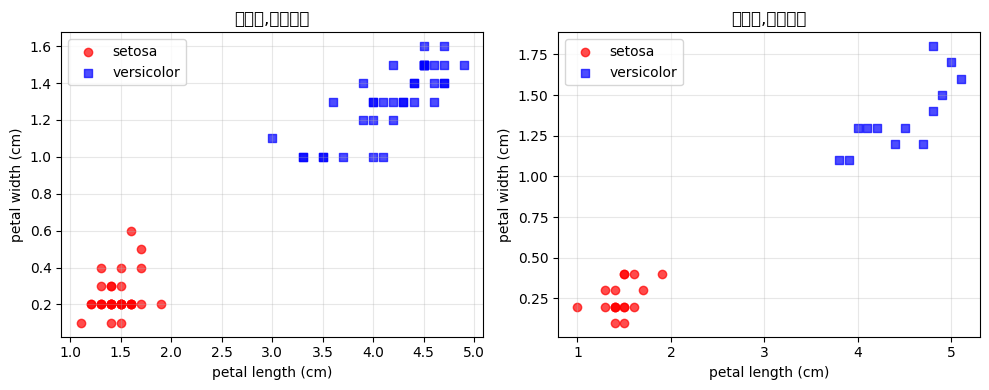

d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: 

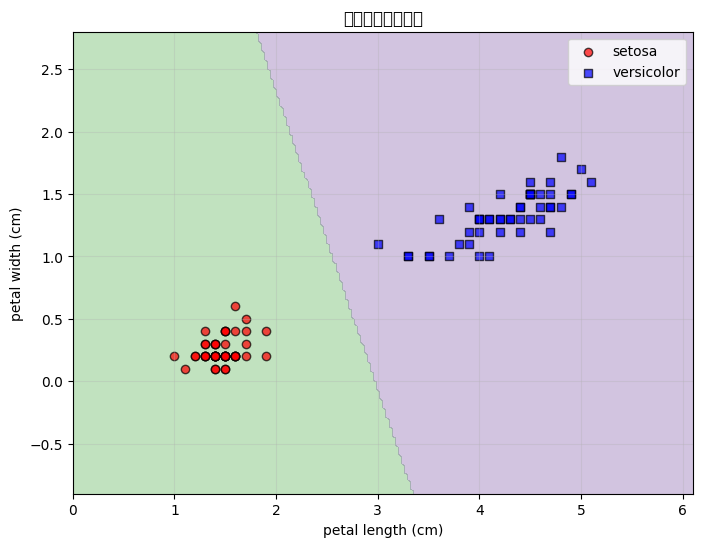

In [10]:
# 只用花瓣长度和宽度两个特征进行二分类和可视化
X_two_features = X_binary[:, 2:4]
X_train, X_test, y_train, y_test = train_test_split(X_two_features, y_binary, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# 绘制两个特征的散点图
plt.figure(figsize=(10,4))
# 训练集
plt.subplot(1,2,1)
for label, color, marker in zip([0,1], ['red','blue'], ['o','s']):
    mask = (y_train == label)
    plt.scatter(X_train[mask,0], X_train[mask,1], c=color, marker=marker, label=iris.target_names[label], alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("训练集,真实标签")
plt.legend()
plt.grid(True, alpha=0.3)

# 测试集预测结果
plt.subplot(1,2,2)
y_test_pred = model.predict(X_test)
for label, color, marker in zip([0,1], ['red','blue'], ['o','s']):
    mask = (y_test_pred == label)
    plt.scatter(X_test[mask,0], X_test[mask,1], c=color, marker=marker, label=iris.target_names[label], alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("测试集,预测标签")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 绘制决策边界
plt.figure(figsize=(8,6))
x_min, x_max = X_two_features[:, 0].min() - 1, X_two_features[:, 0].max() + 1
y_min, y_max = X_two_features[:, 1].min() - 1, X_two_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(-0.5, 2), cmap=plt.cm.Paired)
# 绘制所有数据点
for label, color, marker in zip([0,1], ['red','blue'], ['o','s']):
    mask = (y_binary == label)
    plt.scatter(X_two_features[mask,0], X_two_features[mask,1], c=color, marker=marker, label=iris.target_names[label], edgecolor='k', alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("决策边界与数据点")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# 10.1 尝试不同的正则化强度
print("不同正则化强度C的效果:")
for C in [0.01, 0.1, 1, 10, 100]:
    model_tmp = LogisticRegression(C=C, random_state=42, max_iter=1000)
    model_tmp.fit(X_train, y_train)
    acc = model_tmp.score(X_test, y_test)
    print(f"C={C:5}: 测试集准确率={acc:.3f}, 系数绝对值平均={np.mean(np.abs(model_tmp.coef_)):.3f}")

# 10.2 尝试不划分测试集会怎样（错误示范）
print("\n--- 警告：错误示范 ---")
model_wrong = LogisticRegression(random_state=42)
model_wrong.fit(X_binary, y_binary)  # 用全部数据训练
y_wrong_pred = model_wrong.predict(X_binary)  # 用同样数据预测
wrong_acc = accuracy_score(y_binary, y_wrong_pred)
print(f"用全部数据训练并在相同数据上评估的准确率: {wrong_acc:.1%}")
print("这个数字具有欺骗性！它不代表模型泛化能力。")

不同正则化强度C的效果:
C= 0.01: 测试集准确率=1.000, 系数绝对值平均=0.239
C=  0.1: 测试集准确率=1.000, 系数绝对值平均=0.837
C=    1: 测试集准确率=1.000, 系数绝对值平均=1.702
C=   10: 测试集准确率=1.000, 系数绝对值平均=2.846
C=  100: 测试集准确率=1.000, 系数绝对值平均=4.315

--- 警告：错误示范 ---
用全部数据训练并在相同数据上评估的准确率: 100.0%
这个数字具有欺骗性！它不代表模型泛化能力。


## 🔄 逻辑回归如何做多分类？
逻辑回归本质是二分类模型，但有两种主要方法扩展到多分类：

方法1：一对多（One-vs-Rest, OvR）
为每个类别训练一个二分类器
每个分类器判断“是当前类别”还是“不是当前类别”
预测时选择概率最高的那个类别

方法2：多项式逻辑回归（Multinomial/Softmax）
直接输出多个类别的概率
使用softmax函数代替sigmoid函数
这是更自然的扩展方式


In [12]:
# 加载完整鸢尾花数据（三类）
iris = datasets.load_iris()
X = iris.data
y = iris.target

print("数据集信息:")
print(f"特征形状: {X.shape}")  # (150, 4)
print(f"标签形状: {y.shape}")  # (150,)
print(f"类别标签: {np.unique(y)}")
print(f"类别名称: {iris.target_names}")
print(f"各类样本数: {np.bincount(y)}")

数据集信息:
特征形状: (150, 4)
标签形状: (150,)
类别标签: [0 1 2]
类别名称: ['setosa' 'versicolor' 'virginica']
各类样本数: [50 50 50]


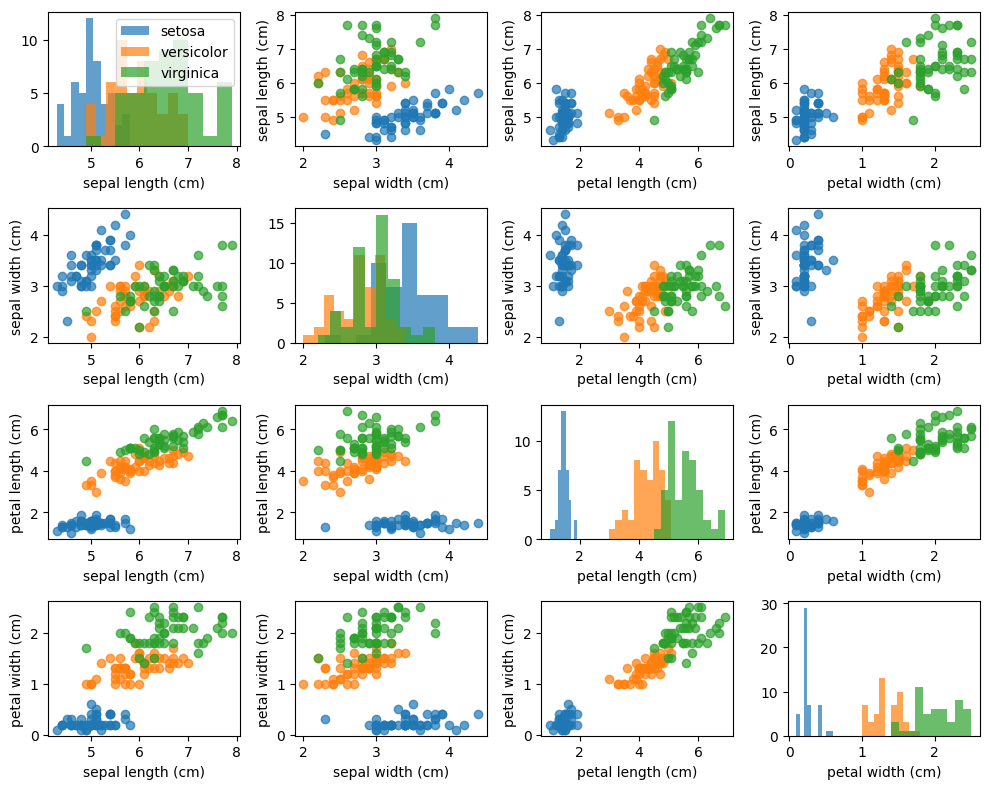

In [13]:
#观察三类数据的特征分布

# 可视化三类数据在两个特征上的分布
plt.figure(figsize=(10, 8))

# 创建4x4的特征组合图
feature_names = iris.feature_names
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, i*4 + j + 1)
        if i == j:
            # 对角线：直方图
            for target in range(3):
                plt.hist(X[y == target, i], alpha=0.7, label=iris.target_names[target])
            plt.xlabel(feature_names[i])
            if i == 0:
                plt.legend()
        else:
            # 非对角线：散点图
            for target in range(3):
                plt.scatter(X[y == target, j], X[y == target, i], alpha=0.7, label=iris.target_names[target])
            plt.xlabel(feature_names[j])
            plt.ylabel(feature_names[i])
        if i == 0 and j == 0:
            plt.legend()

plt.tight_layout()
plt.show()


### 训练多分类逻辑回归


In [14]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# stratify参数确保每个类别的分布一致

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")
print("训练集类别分布:", np.bincount(y_train))
print("测试集类别分布:", np.bincount(y_test))

# 方法1：使用默认的OvR（一对多）
model_ovr = LogisticRegression(random_state=42, max_iter=1000)
model_ovr.fit(X_train, y_train)

# 方法2：使用多项式逻辑回归（softmax）
model_softmax = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    multi_class='multinomial',  # 关键参数
    solver='lbfgs'  # 多项逻辑回归需要支持它的求解器
)
model_softmax.fit(X_train, y_train)

print("\n模型训练完成!")

训练集大小: 105
测试集大小: 45
训练集类别分布: [35 35 35]
测试集类别分布: [15 15 15]

模型训练完成!


d:\1\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [15]:
#比较两种方法
# 预测
y_pred_ovr = model_ovr.predict(X_test)
y_pred_softmax = model_softmax.predict(X_test)

# 评估
print("=== 一对多 (OvR) 方法 ===")
print(f"准确率: {accuracy_score(y_test, y_pred_ovr):.3f}")
print("\n混淆矩阵:")
print(confusion_matrix(y_test, y_pred_ovr))

print("\n=== 多项式逻辑回归 (Softmax) 方法 ===")
print(f"准确率: {accuracy_score(y_test, y_pred_softmax):.3f}")
print("\n混淆矩阵:")
print(confusion_matrix(y_test, y_pred_softmax))

# 查看详细的分类报告
print("\n=== OvR分类报告 ===")
print(classification_report(y_test, y_pred_ovr, target_names=iris.target_names))

print("\n=== Softmax分类报告 ===")
print(classification_report(y_test, y_pred_softmax, target_names=iris.target_names))

=== 一对多 (OvR) 方法 ===
准确率: 0.933

混淆矩阵:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]

=== 多项式逻辑回归 (Softmax) 方法 ===
准确率: 0.933

混淆矩阵:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]

=== OvR分类报告 ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


=== Softmax分类报告 ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [16]:
# 查看softmax模型的预测概率
print("前5个测试样本的预测概率:")
probs = model_softmax.predict_proba(X_test[:5])
for i, (prob, true_label, pred_label) in enumerate(zip(probs, y_test[:5], y_pred_softmax[:5])):
    print(f"\n样本{i}:")
    for class_idx in range(3):
        print(f"  属于{iris.target_names[class_idx]}的概率: {prob[class_idx]:.4f}", 
              end="")
        if class_idx == pred_label:
            print(" ← 预测类别")
        else:
            print()
    print(f"  真实标签: {iris.target_names[true_label]}")

# 查看模型参数
print("\n=== Softmax模型参数 ===")
print("系数形状 (coef_):", model_softmax.coef_.shape)  # (3, 4)
print("截距形状 (intercept_):", model_softmax.intercept_.shape)  # (3,)

print("\n每个类别的系数:")
for i, (coef, intercept) in enumerate(zip(model_softmax.coef_, model_softmax.intercept_)):
    print(f"\n{iris.target_names[i]}的决策函数:")
    print(f"  z_{i} = {intercept:.3f}", end="")
    for j, c in enumerate(coef):
        print(f" + ({c:.3f})*{iris.feature_names[j]}", end="")
    print()

前5个测试样本的预测概率:

样本0:
  属于setosa的概率: 0.0000
  属于versicolor的概率: 0.0323
  属于virginica的概率: 0.9677 ← 预测类别
  真实标签: virginica

样本1:
  属于setosa的概率: 0.0045
  属于versicolor的概率: 0.7638 ← 预测类别
  属于virginica的概率: 0.2317
  真实标签: versicolor

样本2:
  属于setosa的概率: 0.0009
  属于versicolor的概率: 0.5056 ← 预测类别
  属于virginica的概率: 0.4935
  真实标签: virginica

样本3:
  属于setosa的概率: 0.0051
  属于versicolor的概率: 0.6617 ← 预测类别
  属于virginica的概率: 0.3332
  真实标签: versicolor

样本4:
  属于setosa的概率: 0.0017
  属于versicolor的概率: 0.4096
  属于virginica的概率: 0.5887 ← 预测类别
  真实标签: virginica

=== Softmax模型参数 ===
系数形状 (coef_): (3, 4)
截距形状 (intercept_): (3,)

每个类别的系数:

setosa的决策函数:
  z_0 = 9.928 + (-0.545)*sepal length (cm) + (0.764)*sepal width (cm) + (-2.229)*petal length (cm) + (-0.975)*petal width (cm)

versicolor的决策函数:
  z_1 = 2.423 + (0.421)*sepal length (cm) + (-0.427)*sepal width (cm) + (-0.100)*petal length (cm) + (-0.839)*petal width (cm)

virginica的决策函数:
  z_2 = -12.351 + (0.124)*sepal length (cm) + (-0.337)*sepal width (cm) + (2.329)*pet

d:\1\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  fig.canvas.print

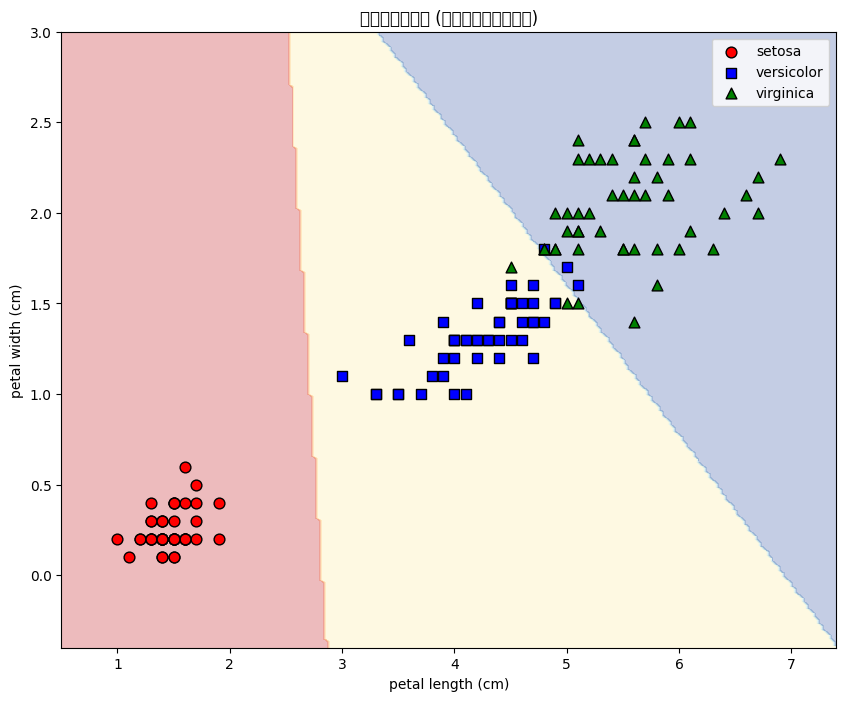

In [17]:
#可视化决策边界
# 为了可视化，我们只使用两个特征
feature1, feature2 = 2, 3  # 花瓣长度和宽度
X_2d = X[:, [feature1, feature2]]

# 重新训练模型
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)

model_2d = LogisticRegression(random_state=42, multi_class='multinomial')
model_2d.fit(X_train_2d, y_train_2d)

# 绘制决策边界
plt.figure(figsize=(10, 8))

# 创建网格
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# 预测整个网格
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策区域
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

# 绘制数据点
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']
for i, (color, marker) in enumerate(zip(colors, markers)):
    plt.scatter(X_2d[y == i, 0], X_2d[y == i, 1],
                c=color, marker=marker, 
                label=iris.target_names[i],
                edgecolor='black', s=60)

plt.xlabel(iris.feature_names[feature1])
plt.ylabel(iris.feature_names[feature2])
plt.title("多分类决策边界 (使用花瓣长度和宽度)")
plt.legend()
plt.show()

## 📊 理解多分类的关键点
1. 模型参数的变化
在二分类中：
coef_形状：(1, n_features)
intercept_形状：(1,)
在多分类中：
coef_形状：(n_classes, n_features) - 每个类别有自己的系数向量
intercept_形状：(n_classes,) - 每个类别有自己的截距
2. 决策过程
对于一个新的样本x：
计算每个类别的得分：

使用softmax函数转换为概率：P(y=k∣x)=

选择概率最大的类别作为预测结果
3. 一对多 vs 多项式
一对多：训练K个二分类器，每个判断"是类别k" vs "不是类别k"
多项式：一个模型直接输出K个类别的概率分布
通常多项式更自然，但计算量稍大。在实践中，两种方法效果通常相似。

In [18]:
# 找出预测错误的样本
errors = np.where(y_pred_softmax != y_test)[0]
print(f"错误分类的样本数: {len(errors)}")

# 查看第一个错误样本
if len(errors) > 0:
    idx = errors[0]
    print(f"\n第一个错误样本:")
    print(f"  真实类别: {iris.target_names[y_test[idx]]}")
    print(f"  预测类别: {iris.target_names[y_pred_softmax[idx]]}")
    print(f"  特征值: {X_test[idx]}")
    print(f"  各类别概率: {model_softmax.predict_proba(X_test[idx:idx+1])[0]}")

错误分类的样本数: 3

第一个错误样本:
  真实类别: virginica
  预测类别: versicolor
  特征值: [6.3 2.8 5.1 1.5]
  各类别概率: [0.00092375 0.50559418 0.49348207]


## 特征选择

第一层：基于统计和可视化的初步筛选

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
matplotlib.rcParams['axes.unicode_minus'] = False    # 正常显示负号

In [29]:
# 加载数据
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = [iris.target_names[t] for t in y]

print("=== 特征统计分析 ===")
print(df.describe())

=== 特征统计分析 ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [30]:
# 1. 查看特征与目标的相关性（适用于回归或可量化的分类）
print("\n=== 特征与目标的相关性 ===")
# 计算每个特征与目标的相关性（注意：目标需要是数值型）
correlations = df.drop('target_name', axis=1).corr()['target'].abs().sort_values(ascending=False)
print("特征与目标的绝对相关性（绝对值越大越相关）:")
print(correlations[1:])  # 排除目标自己


=== 特征与目标的相关性 ===
特征与目标的绝对相关性（绝对值越大越相关）:
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)     0.426658
Name: target, dtype: float64


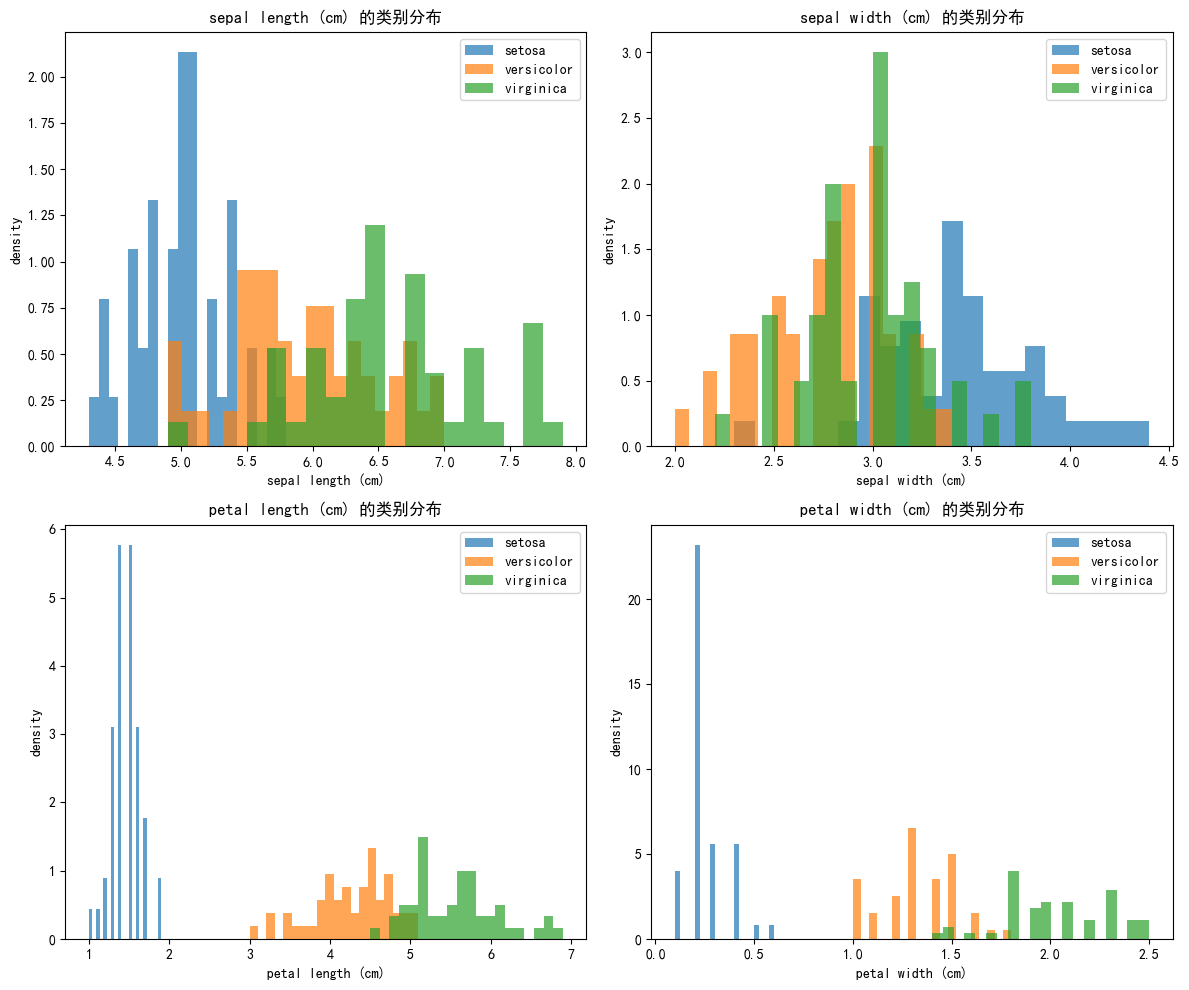

In [31]:
# 2. 可视化特征分布
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, feature in enumerate(feature_names):
    ax = axes[idx//2, idx%2]
    for target_class in range(3):
        ax.hist(df[df['target'] == target_class][feature], 
                alpha=0.7, label=iris.target_names[target_class], 
                bins=20, density=True)
    ax.set_xlabel(feature)
    ax.set_ylabel('density')
    ax.legend()
    ax.set_title(f'{feature} 的类别分布')
plt.tight_layout()
plt.show()



=== 特征间的相关性矩阵 ===


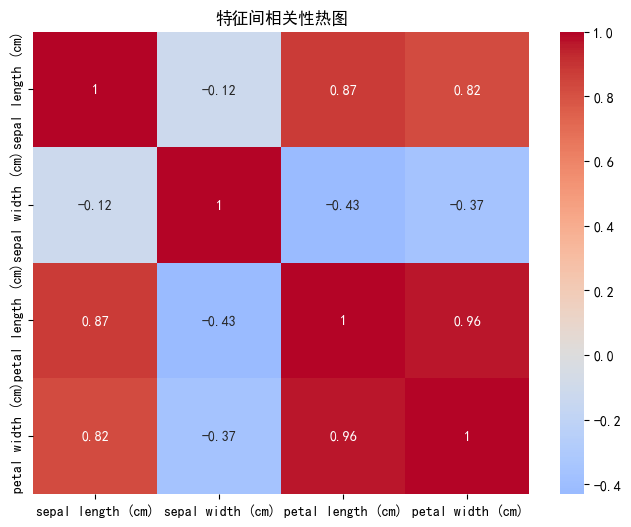

In [32]:
# 3. 特征间的相关性（避免多重共线性）
print("\n=== 特征间的相关性矩阵 ===")
feature_corr = df[feature_names].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(feature_corr, annot=True, cmap='coolwarm', center=0)
plt.title('特征间相关性热图')
plt.show()

## 关键观察：

哪些特征的类别分布差异大？→ 可能区分能力强

哪些特征间高度相关（|r| > 0.8）？→ 考虑只保留一个

比如在鸢尾花数据中，你会发现花瓣特征比花萼特征区分度更好

##  第二层：基于模型的特征重要性评估

=== 不同特征组合的效果 ===
                                             features  num_features  \
2                                 [petal length (cm)]             1   
5              [sepal length (cm), petal length (cm)]             2   
3                                  [petal width (cm)]             1   
12  [sepal length (cm), petal length (cm), petal w...             3   
10  [sepal length (cm), sepal width (cm), petal le...             3   
9               [petal length (cm), petal width (cm)]             2   
7               [sepal width (cm), petal length (cm)]             2   
14  [sepal length (cm), sepal width (cm), petal le...             4   
13  [sepal width (cm), petal length (cm), petal wi...             3   
11  [sepal length (cm), sepal width (cm), petal wi...             3   

    train_accuracy  test_accuracy feature_indices  
2         0.961905       0.933333             [2]  
5         0.971429       0.933333          [0, 2]  
3         0.971429       0.933333           

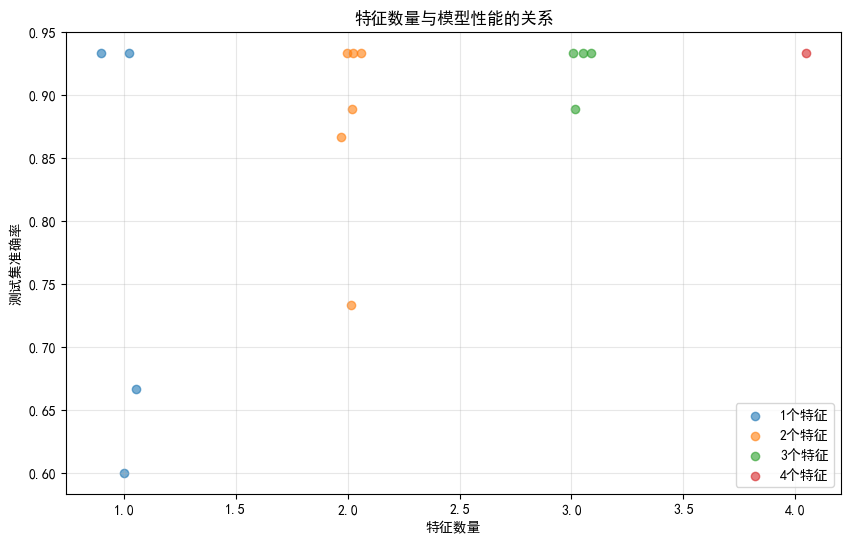

In [34]:
# 方法1：基于逻辑回归系数的绝对值
def evaluate_feature_sets(X, y, feature_names, test_size=0.3):
    """评估不同特征组合的效果"""
    results = []
    
    # 所有可能的特征组合（2^4 - 1 = 15种，排除空集）
    from itertools import combinations
    
    for k in range(1, len(feature_names) + 1):
        for combo in combinations(range(len(feature_names)), k):
            combo = list(combo)
            feature_subset = [feature_names[i] for i in combo]
            
            # 使用选定的特征
            X_subset = X[:, combo]
            
            # 划分数据
            X_train, X_test, y_train, y_test = train_test_split(
                X_subset, y, test_size=test_size, random_state=42, stratify=y
            )
            
            # 训练模型
            model = LogisticRegression(random_state=42, max_iter=1000)
            model.fit(X_train, y_train)
            
            # 评估
            train_acc = model.score(X_train, y_train)
            test_acc = model.score(X_test, y_test)
            
            # 存储结果
            results.append({
                'features': feature_subset,
                'num_features': k,
                'train_accuracy': train_acc,
                'test_accuracy': test_acc,
                'feature_indices': combo
            })
    
    return pd.DataFrame(results)

# 评估所有特征组合
results_df = evaluate_feature_sets(X, y, feature_names)
print("=== 不同特征组合的效果 ===")
print(results_df.sort_values('test_accuracy', ascending=False).head(10))

# 可视化特征组合效果
plt.figure(figsize=(10, 6))
for num_feat in range(1, 5):
    subset = results_df[results_df['num_features'] == num_feat]
    plt.scatter(subset['num_features'] + np.random.normal(0, 0.05, len(subset)), 
                subset['test_accuracy'], alpha=0.6, label=f'{num_feat}个特征')
plt.xlabel('特征数量')
plt.ylabel('测试集准确率')
plt.title('特征数量与模型性能的关系')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 系统化的特征选择方法
适用于：​ 正式项目中的自动化特征选择

=== 方法1: 基于统计检验的特征选择 ===
特征得分（F值越大，特征越重要）:
                  特征          F值            P值
2  petal length (cm)  814.733158  1.903235e-63
3   petal width (cm)  791.349745  7.690669e-63
0  sepal length (cm)   95.760855  3.881120e-24
1   sepal width (cm)   33.059484  8.553747e-12

=== 方法2: 基于模型的特征重要性 ===
L1正则化后的特征系数（系数为0的特征可以被剔除）:
                  特征        系数
0  sepal length (cm)  0.000000
1   sepal width (cm)  2.327575
2  petal length (cm) -2.606587
3   petal width (cm)  0.000000

非零系数特征数: 10

=== 方法3: 递归特征消除(RFE) ===
特征被选择的排名（1表示被选择）:
sepal length (cm): 是否选中=False, 排名=3
sepal width (cm): 是否选中=False, 排名=2
petal length (cm): 是否选中=True, 排名=1
petal width (cm): 是否选中=True, 排名=1

=== 不同特征数量的效果比较 ===
选择1个特征: [np.str_('petal length (cm)')] -> 测试准确率: 0.933
选择2个特征: [np.str_('petal length (cm)'), np.str_('petal width (cm)')] -> 测试准确率: 0.933
选择3个特征: [np.str_('sepal length (cm)'), np.str_('petal length (cm)'), np.str_('petal width (cm)')] -> 测试准确率: 0.933
选择4个特征: [np.str_('sepal length (cm)'), np.st

d:\1\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


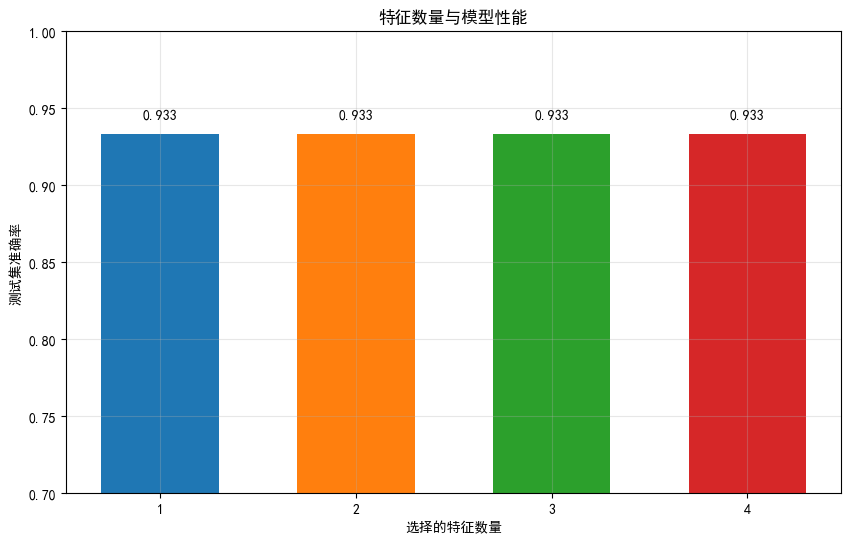

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 重新划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 方法1：基于统计检验的特征选择（过滤法）
print("=== 方法1: 基于统计检验的特征选择 ===")
# 使用ANOVA F检验（适用于分类问题）
selector_f = SelectKBest(score_func=f_classif, k='all')  # 先选所有，看分数
selector_f.fit(X_train, y_train)

# 查看每个特征的分数
feature_scores = pd.DataFrame({
    '特征': feature_names,
    'F值': selector_f.scores_,
    'P值': selector_f.pvalues_
})
print("特征得分（F值越大，特征越重要）:")
print(feature_scores.sort_values('F值', ascending=False))

# 方法2：基于模型的特征选择（嵌入法）
print("\n=== 方法2: 基于模型的特征重要性 ===")
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# 查看L1正则化后的系数（L1会使不重要的特征系数为0）
coef_df = pd.DataFrame({
    '特征': feature_names,
    '系数': model.coef_[0]  # 多分类时每个类别都有系数，这里简单取第一个
})
print("L1正则化后的特征系数（系数为0的特征可以被剔除）:")
print(coef_df)
print(f"\n非零系数特征数: {(np.abs(model.coef_) > 0).sum()}")

# 方法3：递归特征消除（RFE）- 包装法
print("\n=== 方法3: 递归特征消除(RFE) ===")
# RFE会递归地移除最不重要的特征
estimator = LogisticRegression(random_state=42, max_iter=1000)
selector_rfe = RFE(estimator=estimator, n_features_to_select=2)  # 选择2个特征
selector_rfe.fit(X_train, y_train)

print("特征被选择的排名（1表示被选择）:")
for i, (name, selected, rank) in enumerate(zip(feature_names, selector_rfe.support_, selector_rfe.ranking_)):
    print(f"{name}: 是否选中={selected}, 排名={rank}")

# 测试不同特征数量的效果
print("\n=== 不同特征数量的效果比较 ===")
plt.figure(figsize=(10, 6))

for k in range(1, len(feature_names) + 1):
    # 使用Pipeline整合特征选择和模型
    pipeline = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=k)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])
    
    pipeline.fit(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)
    
    # 获取被选中的特征
    selected_mask = pipeline.named_steps['selector'].get_support()
    selected_features = np.array(feature_names)[selected_mask]
    
    print(f"选择{k}个特征: {list(selected_features)} -> 测试准确率: {test_acc:.3f}")
    
    # 可视化
    plt.bar(k, test_acc, width=0.6)
    plt.text(k, test_acc + 0.01, f'{test_acc:.3f}', ha='center')

plt.xlabel('选择的特征数量')
plt.ylabel('测试集准确率')
plt.title('特征数量与模型性能')
plt.xticks(range(1, len(feature_names) + 1))
plt.ylim(0.7, 1.0)
plt.grid(True, alpha=0.3)
plt.show()

## 📊 特征选择的实战策略
策略1：从简单到复杂

In [36]:
def incremental_feature_selection(X, y, feature_names):
    """逐步添加特征，观察性能变化"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 按单个特征的重要性排序
    single_feat_scores = []
    for i, feat_name in enumerate(feature_names):
        X_single = X_train[:, i:i+1]  # 单个特征
        
        model = LogisticRegression(random_state=42, max_iter=1000)
        scores = cross_val_score(model, X_single, y_train, cv=3, scoring='accuracy')
        single_feat_scores.append((feat_name, scores.mean()))
    
    # 按性能排序
    single_feat_scores.sort(key=lambda x: x[1], reverse=True)
    print("单个特征性能排序:")
    for feat_name, score in single_feat_scores:
        print(f"  {feat_name}: {score:.3f}")
    
    # 逐步添加特征
    selected_features = []
    accuracies = []
    
    for feat_name, _ in single_feat_scores:
        selected_features.append(feat_name)
        feat_indices = [feature_names.index(f) for f in selected_features]
        X_selected = X_train[:, feat_indices]
        
        model = LogisticRegression(random_state=42, max_iter=1000)
        scores = cross_val_score(model, X_selected, y_train, cv=3, scoring='accuracy')
        mean_acc = scores.mean()
        accuracies.append(mean_acc)
        
        print(f"使用特征 {selected_features}: 准确率 = {mean_acc:.3f}")
    
    # 可视化
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(accuracies)+1), accuracies, 'o-', linewidth=2, markersize=8)
    plt.xlabel('特征数量')
    plt.ylabel('交叉验证准确率')
    plt.title('逐步添加特征的效果')
    plt.xticks(range(1, len(feature_names)+1))
    plt.grid(True, alpha=0.3)
    
    # 标记最佳点
    best_idx = np.argmax(accuracies)
    plt.scatter(best_idx+1, accuracies[best_idx], color='red', s=200, zorder=5, 
                label=f'最佳: {best_idx+1}个特征')
    plt.legend()
    plt.show()
    
    return selected_features[:best_idx+1]  # 返回最佳特征子集

In [39]:
def create_interaction_features(X, feature_names):
    """创建特征交互项"""
    from itertools import combinations
    
    n_samples, n_features = X.shape
    interaction_features = []
    interaction_names = []
    
    # 原始特征
    interaction_features.append(X)
    interaction_names.extend(feature_names)
    
    # 两两乘积（交互项）
    for (i, j) in combinations(range(n_features), 2):
        interaction = X[:, i] * X[:, j]
        interaction_features.append(interaction.reshape(-1, 1))
        interaction_names.append(f"{feature_names[i]}×{feature_names[j]}")
    
    # 平方项
    for i in range(n_features):
        square = X[:, i] ** 2
        interaction_features.append(square.reshape(-1, 1))
        interaction_names.append(f"{feature_names[i]}²")
    
    X_interaction = np.hstack(interaction_features)
    return X_interaction, interaction_names

# 尝试创建交互特征
X_interaction, interaction_names = create_interaction_features(X, feature_names)
print(f"原始特征数: {len(feature_names)}")
print(f"添加交互项后: {len(interaction_names)}")
print(f"新特征示例: {interaction_names[-5:]}")

原始特征数: 4
添加交互项后: 14
新特征示例: ['petal length (cm)×petal width (cm)', 'sepal length (cm)²', 'sepal width (cm)²', 'petal length (cm)²', 'petal width (cm)²']


In [38]:
def feature_selection_workflow(X, y, feature_names):
    """完整的特征选择工作流程"""
    print("步骤1: 数据探索")
    df = pd.DataFrame(X, columns=feature_names)
    df['target'] = y
    
    # 计算每个特征的方差（低方差特征可能信息量少）
    variances = df[feature_names].var()
    print(f"特征方差:\n{varities}")
    
    # 计算特征与目标的相关性
    if len(np.unique(y)) > 2:
        # 多分类：使用方差分析F值
        from sklearn.feature_selection import f_classif
        f_values, p_values = f_classif(X, y)
        print(f"\nF值（越大越好）:")
        for name, f_val, p_val in zip(feature_names, f_values, p_values):
            print(f"{name}: F={f_val:.2f}, p={p_val:.4f}")
    else:
        # 二分类：可以计算相关性
        correlations = df.corr()['target'].abs()
        print(f"\n与目标的绝对相关性:\n{correlations.sort_values(ascending=False)}")
    
    print("\n步骤2: 可视化分析")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for idx, feature in enumerate(feature_names):
        ax = axes[idx//2, idx%2]
        for target_class in sorted(np.unique(y)):
            subset = df[df['target'] == target_class][feature]
            ax.hist(subset, alpha=0.5, label=f'Class {target_class}', bins=20)
        ax.set_xlabel(feature)
        ax.set_ylabel('频数')
        ax.legend()
    plt.tight_layout()
    plt.show()
    
    print("\n步骤3: 特征选择方法比较")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    methods = {
        '所有特征': X_train,
        '方差前2': None,  # 需要实现
        'F检验前2': None,
        '模型选择': None
    }
    
    # 比较不同特征选择方法
    results = []
    for method_name, X_train_subset in methods.items():
        if X_train_subset is not None:
            model = LogisticRegression(random_state=42, max_iter=1000)
            model.fit(X_train_subset, y_train)
            test_acc = model.score(X_test, y_test)
            results.append((method_name, test_acc))
    
    # 显示结果
    print("特征选择方法比较:")
    for method_name, acc in sorted(results, key=lambda x: x[1], reverse=True):
        print(f"  {method_name}: {acc:.3f}")
    
    return results

# 运行工作流程
feature_selection_workflow(X, y, feature_names)

步骤1: 数据探索


NameError: name 'varities' is not defined

In [37]:
# 创建一个函数，系统地尝试所有特征组合
def find_best_feature_combination(X, y, feature_names, max_features=None):
    """寻找最佳特征组合"""
    from itertools import combinations
    
    if max_features is None:
        max_features = len(feature_names)
    
    best_score = 0
    best_features = None
    results = []
    
    for k in range(1, max_features + 1):
        for combo in combinations(range(len(feature_names)), k):
            # 使用当前特征组合
            X_subset = X[:, list(combo)]
            
            # 使用交叉验证评估稳定性
            from sklearn.model_selection import cross_val_score
            model = LogisticRegression(random_state=42, max_iter=1000)
            scores = cross_val_score(model, X_subset, y, cv=5, scoring='accuracy')
            mean_score = scores.mean()
            std_score = scores.std()
            
            # 记录结果
            feature_list = [feature_names[i] for i in combo]
            results.append({
                'features': feature_list,
                'num_features': k,
                'mean_score': mean_score,
                'std_score': std_score,
                'combo': combo
            })
            
            # 更新最佳结果（考虑均值和稳定性）
            score_value = mean_score - 0.1 * std_score  # 惩罚不稳定
            if score_value > best_score:
                best_score = score_value
                best_features = feature_list
    
    results_df = pd.DataFrame(results)
    return results_df.sort_values('mean_score', ascending=False), best_features, best_score

# 运行特征搜索
print("=== 系统搜索最佳特征组合（使用5折交叉验证）===")
all_results, best_features, best_score = find_best_feature_combination(X, y, feature_names)

print("Top 10特征组合:")
for i, row in all_results.head(10).iterrows():
    print(f"{i+1:2d}. 特征{row['num_features']}个: {row['features']} -> 平均准确率: {row['mean_score']:.3f} (±{row['std_score']:.3f})")

print(f"\n最佳特征组合: {best_features}")
print(f"最佳得分: {best_score:.3f}")

=== 系统搜索最佳特征组合（使用5折交叉验证）===
Top 10特征组合:
15. 特征4个: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] -> 平均准确率: 0.973 (±0.025)
13. 特征3个: ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)'] -> 平均准确率: 0.967 (±0.021)
14. 特征3个: ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] -> 平均准确率: 0.967 (±0.021)
10. 特征2个: ['petal length (cm)', 'petal width (cm)'] -> 平均准确率: 0.960 (±0.025)
 4. 特征1个: ['petal width (cm)'] -> 平均准确率: 0.960 (±0.039)
 6. 特征2个: ['sepal length (cm)', 'petal length (cm)'] -> 平均准确率: 0.953 (±0.040)
 3. 特征1个: ['petal length (cm)'] -> 平均准确率: 0.953 (±0.040)
 8. 特征2个: ['sepal width (cm)', 'petal length (cm)'] -> 平均准确率: 0.953 (±0.040)
11. 特征3个: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)'] -> 平均准确率: 0.953 (±0.040)
 7. 特征2个: ['sepal length (cm)', 'petal width (cm)'] -> 平均准确率: 0.953 (±0.027)

最佳特征组合: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
最佳得分: 0.971


## 🎯 特征选择的经验法则
何时使用何种方法？             
情况                       推荐方法             原因

特征 < 20                  尝试所有组合                计算量可接受
	
特征 20-100          过滤法 + 嵌入法                平衡效果和效率

特征 > 100            过滤法                   先大幅减少特征数量
	
特征间高度相关        先去除相关性高的            避免多重共线性

线性模型               L1正则化                       天然特征选择
	
树模型                 基于重要性                 内置特征重要性

你的检查清单：

数据探索：每个特征的分布、缺失值、异常值

单变量分析：特征与目标的关系（相关性、F检验等）

特征重要性：用简单模型评估特征重要性

迭代优化：尝试不同特征子集，用交叉验证评估

最终验证：在完全独立的测试集上验证